# Continuation models — ensemble comparison

Compare any subset of the three methods from
`runnable_code/run_continuation_models.py`:

- **`etas`** — classic ETAS branching process
- **`thinning`** — Ogata thinning (`simulate_magnitudes`)
- **`thinning_magnet`** — Ogata thinning + MAGNET (`MAGNET_magnitude`)

Layout (model-keyed, not batch-keyed)::

```
<output_root>/<method>/inv_<inversion_id>/seed_<seed>/forecast_catalog.csv
<output_root>/<method>/inv_<inversion_id>/seed_<seed>/realization_meta.json
# optional, when magnet.save_predictions / --save-magnet-predictions:
<output_root>/thinning_magnet/inv_<id>/seed_<seed>/magnet_predictions.npz
```

Edit the **User config** cell to pick `OUTPUT_ROOT`, which methods to load
(1, 2, or 3), seed selection, and which MAGNET events to plot as Kumaraswamy PDFs.


In [1]:
%matplotlib inline
from __future__ import annotations

import json
import math
import re
import sys
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats

CONTINUATION_METHODS = ("etas", "thinning", "thinning_magnet")
_FORECAST_CATALOG_NAME = "forecast_catalog.csv"
_REALIZATION_META_NAME = "realization_meta.json"
_MAGNET_PREDICTIONS_NAME = "magnet_predictions.npz"

METHOD_LABELS = {
    "etas": "Classic ETAS",
    "thinning": "Thinning",
    "thinning_magnet": "Thinning + MAGNET",
}
METHOD_COLORS = {
    "etas": "seagreen",
    "thinning": "indianred",
    "thinning_magnet": "royalblue",
}


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


In [2]:
# ---------------------------------------------------------------------------
# User config — edit these
# ---------------------------------------------------------------------------

def find_repo_root() -> Path:
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "run_continuation_models.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Set the kernel cwd to the repo or notebooks/ folder."
    )


REPO_ROOT = find_repo_root()

for _candidate in [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

# Default: run_continuation_models.py output root (config "output_root").
OUTPUT_ROOT = REPO_ROOT / "outputs/continuation_models"

# Which methods to compare. None → auto-discover whatever exists under OUTPUT_ROOT.
# Examples: ["thinning", "thinning_magnet"]  |  ["etas"]  |  ["etas", "thinning", "thinning_magnet"]
METHODS: list[str] | None = None

# Pin a specific inversion id, or None to pick the newest inv_* shared by selected methods.
INVERSION_ID: str | None = '219e51f42e5469be'  # e.g. "219e51f42e5469be" or None

# Seed selection
LOAD_MODE: Literal["all", "first_n", "seeds"] = "first_n"
FIRST_N: int = 5
SEEDS: list[int] = [0, 1, 2, 3, 4]

# ---------------------------------------------------------------------------
# MAGNET Kumaraswamy samples (only when thinning_magnet + magnet_predictions.npz)
# ---------------------------------------------------------------------------
# Realization to inspect (None → first selected seed that has a sidecar).
MAGNET_PRED_SEED: int | None = None

# How to pick events for PDF plots:
#   "indices"          — use KUMA_EVENT_INDICES (0-based rows in npz / catalog)
#   "largest_m"        — top KUMA_N_EVENTS by sampled magnitude
#   "first_n"          — first KUMA_N_EVENTS rows
#   "magnitude_range"  — events with magnitude in KUMA_MAG_RANGE (up to KUMA_N_EVENTS)
KUMA_EVENT_MODE: Literal["indices", "largest_m", "first_n", "magnitude_range"] = "largest_m"
KUMA_EVENT_INDICES: list[int] = []  # e.g. [0, 12, 50] when mode="indices"
KUMA_N_EVENTS: int = 6
KUMA_MAG_RANGE: tuple[float, float] | None = (6.0, 10.0)  # used when mode="magnitude_range"

# Magnitude-axis support for PDF plots (None → infer from shift/stretch).
KUMA_M_GRID: tuple[float, float, int] | None = None  # (m_lo, m_hi, n_points)


In [3]:
def list_inv_dirs(method_root: Path) -> list[Path]:
    if not method_root.is_dir():
        return []
    return sorted(
        [p for p in method_root.iterdir() if p.is_dir() and p.name.startswith("inv_")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )


def discover_methods(output_root: Path) -> list[str]:
    found = []
    for method in CONTINUATION_METHODS:
        if list_inv_dirs(output_root / method):
            found.append(method)
    return found


def discover_realization_seeds(ensemble_dir: Path) -> list[int]:
    seeds: set[int] = set()
    for path in ensemble_dir.iterdir():
        if path.is_dir() and path.name.startswith("seed_"):
            seeds.add(int(path.name.removeprefix("seed_")))
    if not seeds:
        raise FileNotFoundError(f"No seed_* folders under {ensemble_dir}")
    return sorted(seeds)


def select_seeds(
    available: list[int],
    *,
    mode: Literal["all", "first_n", "seeds"],
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> list[int]:
    if mode == "all":
        return list(available)
    if mode == "first_n":
        if first_n is None or first_n < 1:
            raise ValueError("first_n must be >= 1")
        return available[:first_n]
    if mode == "seeds":
        if not seeds:
            raise ValueError("SEEDS must be non-empty")
        missing = sorted(set(seeds) - set(available))
        if missing:
            raise ValueError(f"Requested seeds not found: {missing}; available: {available}")
        return [s for s in available if s in set(seeds)]
    raise ValueError(f"Unknown mode: {mode!r}")


def resolve_ensemble_dir(
    output_root: Path,
    method: str,
    inversion_id: str | None,
) -> Path:
    method_root = output_root / method
    candidates = list_inv_dirs(method_root)
    if not candidates:
        raise FileNotFoundError(f"No inv_* under {method_root}")
    if inversion_id is not None:
        inv_id = inversion_id.removeprefix("inv_")
        path = method_root / f"inv_{inv_id}"
        if not path.is_dir():
            raise FileNotFoundError(f"Missing {path}")
        return path
    return candidates[0]


def pick_shared_inversion_id(
    output_root: Path,
    methods: list[str],
    inversion_id: str | None,
) -> str:
    if inversion_id is not None:
        return inversion_id.removeprefix("inv_")
    id_sets = []
    for method in methods:
        ids = {p.name.removeprefix("inv_") for p in list_inv_dirs(output_root / method)}
        if not ids:
            raise FileNotFoundError(f"No inv_* for method {method} under {output_root / method}")
        id_sets.append(ids)
    shared = set.intersection(*id_sets) if id_sets else set()
    if not shared:
        raise ValueError(
            f"No shared inversion id across methods {methods} under {output_root}. "
            "Set INVERSION_ID explicitly."
        )
    # Prefer the inv that appears first (newest) for the first method.
    for path in list_inv_dirs(output_root / methods[0]):
        inv = path.name.removeprefix("inv_")
        if inv in shared:
            return inv
    return sorted(shared)[0]


def realization_dir(ensemble_dir: Path, seed: int) -> Path:
    return ensemble_dir / f"seed_{seed}"


def load_forecast_catalog(ensemble_dir: Path, seed: int) -> pd.DataFrame:
    path = realization_dir(ensemble_dir, seed) / _FORECAST_CATALOG_NAME
    if not path.is_file():
        raise FileNotFoundError(path)
    catalog = pd.read_csv(path)
    if "dt_days" in catalog.columns:
        catalog["dt_days"] = pd.to_numeric(catalog["dt_days"], errors="coerce")
    mag_col = "m" if "m" in catalog.columns else "magnitude"
    catalog[mag_col] = pd.to_numeric(catalog[mag_col], errors="coerce")
    if "m" not in catalog.columns and "magnitude" in catalog.columns:
        catalog["m"] = catalog["magnitude"]
    return catalog


def load_realization_meta(ensemble_dir: Path, seed: int) -> dict:
    path = realization_dir(ensemble_dir, seed) / _REALIZATION_META_NAME
    if not path.is_file():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def load_method_ensemble(
    ensemble_dir: Path,
    *,
    mode: Literal["all", "first_n", "seeds"] = "all",
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> tuple[dict[int, pd.DataFrame], list[int], dict]:
    ensemble_dir = ensemble_dir.resolve()
    available = discover_realization_seeds(ensemble_dir)
    selected = select_seeds(available, mode=mode, first_n=first_n, seeds=seeds)
    catalogs = {seed: load_forecast_catalog(ensemble_dir, seed) for seed in selected}
    meta = load_realization_meta(ensemble_dir, selected[0]) if selected else {}
    return catalogs, selected, meta


def interevent_times(event_time_days: np.ndarray) -> np.ndarray:
    event_time_days = np.sort(event_time_days[np.isfinite(event_time_days)])
    if event_time_days.size < 2:
        return np.array([], dtype=float)
    return np.diff(event_time_days)


def median_interevent_days(catalog: pd.DataFrame) -> float:
    if "dt_days" not in catalog.columns or len(catalog) < 2:
        return np.nan
    iet = interevent_times(catalog["dt_days"].to_numpy(dtype=float))
    return float(np.median(iet)) if iet.size else np.nan


def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


def events_per_time_bin(dt_days: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)
    counts, _ = np.histogram(dt_days, bins=bin_edges)
    return counts.astype(float)


def ylim_in_xrange(xs, ys_list, x0, x1, *, pad_frac=0.08):
    mask = (xs >= x0) & (xs <= x1)
    if not np.any(mask):
        return 0.0, 1.0
    vals = [np.asarray(y)[mask] for y in ys_list if np.asarray(y).size == xs.size]
    if not vals:
        return 0.0, 1.0
    ymin = min(float(np.min(v)) for v in vals)
    ymax = max(float(np.max(v)) for v in vals)
    pad = max((ymax - ymin) * pad_frac, 1e-6)
    return ymin - pad, ymax + pad


def add_test_window_inset(ax, x_end, draw_fn, *, loc="upper left", ylims=None):
    axins = inset_axes(ax, width="38%", height="38%", loc=loc, borderpad=0.9)
    draw_fn(axins)
    axins.set_xlim(0.0, x_end)
    if ylims is not None:
        axins.set_ylim(*ylims)
    axins.tick_params(labelsize=7)
    axins.grid(True, alpha=0.3)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", ls=":", lw=0.8)


def draw_cumulative_event_count(
    ax,
    *,
    t_grid,
    curves_by_method: dict[str, np.ndarray],
    slopes_by_method: dict[str, float],
    train_dt_days,
    train_days,
    show_training_slopes=True,
    show_legend=False,
):
    for method, arr in curves_by_method.items():
        color = METHOD_COLORS[method]
        label = METHOD_LABELS[method]
        slope = slopes_by_method[method]
        mean = arr.mean(axis=0)
        if arr.shape[0] > 1:
            q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        else:
            q25 = q75 = mean
        ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2, zorder=2)
        ax.plot(
            t_grid,
            mean,
            color=color,
            lw=2.0,
            zorder=3,
            label=f"{label} mean ({slope:.3f} events/day, n={arr.shape[0]})" if show_legend else None,
        )
    if train_dt_days.size:
        train_curve = cumulative_on_grid(train_dt_days, t_grid)
        ax.plot(
            t_grid,
            train_curve,
            color="black",
            lw=2.0,
            ls="--",
            zorder=4,
            label=f"Training (n={train_dt_days.size})" if show_legend else None,
        )
        if show_training_slopes and train_days > 0:
            train_mask = t_grid < 0.0
            if train_mask.any():
                mark_idx = np.linspace(0, train_mask.sum() - 1, num=min(8, int(train_mask.sum())), dtype=int)
                mark_t = t_grid[train_mask][mark_idx]
                mark_y = train_curve[train_mask][mark_idx]
                segment_days = min(0.2 * train_days, 365.0)
                for t0, y0 in zip(mark_t, mark_y):
                    for method, slope in slopes_by_method.items():
                        ax.plot(
                            [t0, t0 + segment_days],
                            [y0, y0 + slope * segment_days],
                            color=METHOD_COLORS[method],
                            lw=1.5,
                            alpha=0.7,
                        )
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def draw_event_rate_by_bin(
    ax,
    *,
    bin_centers,
    bin_edges,
    bin_curves_by_method: dict[str, np.ndarray],
    train_dt_days,
    include_training=True,
    show_legend=False,
):
    for method, arr in bin_curves_by_method.items():
        ax.plot(
            bin_centers,
            arr.mean(axis=0),
            color=METHOD_COLORS[method],
            lw=2.0,
            label=f"{METHOD_LABELS[method]} mean per bin" if show_legend else None,
        )
    if include_training and train_dt_days.size:
        train_bin_counts = events_per_time_bin(train_dt_days, bin_edges)
        neg_bin_mask = bin_edges[:-1] < 0.0
        ax.plot(
            bin_centers[neg_bin_mask],
            train_bin_counts[neg_bin_mask],
            color="black",
            lw=2.0,
            ls="--",
            label="Training" if show_legend else None,
        )
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def load_intensity_context(output_root: Path, ensemble_dir: Path, meta: dict, seed: int) -> dict:
    from etas.inversion import ETASParameterCalculation

    inv_id = meta.get("inversion_id")
    if not inv_id:
        raise ValueError("realization_meta missing inversion_id")
    inv_dir = output_root / "inversions" / f"inv_{inv_id}"
    params_json = inv_dir / f"parameters_{inv_id}.json"
    if not params_json.is_file():
        raise FileNotFoundError(params_json)
    inversion_output = json.loads(params_json.read_text(encoding="utf-8"))
    etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
    mc = float(etas_inversion.m_ref - etas_inversion.delta_m / 2)
    source_events = etas_inversion.source_events.copy()
    if "xi_plus_1" not in source_events.columns:
        source_events["xi_plus_1"] = 1.0
    auxiliary_catalog = pd.merge(
        source_events,
        etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
        left_index=True,
        right_index=True,
        how="left",
    )
    timewindow_end = meta.get("timewindow_end")
    testwindow_end = meta.get("testwindow_end")
    forecast_start_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    forecast_end_dt = pd.to_datetime(testwindow_end, utc=True).tz_convert(None)
    history_df = auxiliary_catalog.loc[auxiliary_catalog["time"] <= forecast_start_dt].copy()
    history_df = history_df.sort_values("time").reset_index(drop=True)
    history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    forecast_start_t = float(history_df["t"].max()) if len(history_df) else (
        (forecast_start_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    )
    forecast_end_t = (forecast_end_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    return {
        "mc": mc,
        "history_df": history_df,
        "forecast_start_t": forecast_start_t,
        "forecast_days": float(forecast_end_t - forecast_start_t),
        "timewindow_start": inversion_output.get("timewindow_start"),
        "timewindow_end": timewindow_end,
        "testwindow_end": testwindow_end,
    }


# ---- MAGNET prediction helpers (numpy Kumaraswamy; no TF required) ----

def kumaraswamy_pdf(x: np.ndarray, a: float, b: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    a = float(a)
    b = float(b)
    out = np.zeros_like(x, dtype=float)
    mask = (x > 0.0) & (x < 1.0)
    xm = x[mask]
    out[mask] = a * b * np.power(xm, a - 1.0) * np.power(1.0 - np.power(xm, a), b - 1.0)
    return out


def mixture_pdf_normalized(u: np.ndarray, model_prediction: np.ndarray) -> np.ndarray:
    pred = np.asarray(model_prediction, dtype=float).reshape(-1)
    if pred.size % 3 != 0:
        raise ValueError(f"model_prediction length must be 3*n, got {pred.size}")
    n = pred.size // 3
    a = pred[:n]
    b = pred[n : 2 * n]
    weights = pred[2 * n :]
    weights = weights / weights.sum()
    pdf = np.zeros_like(u, dtype=float)
    for ai, bi, wi in zip(a, b, weights):
        pdf += wi * kumaraswamy_pdf(u, ai, bi)
    return pdf


def magnitude_pdf_from_prediction(
    m: np.ndarray,
    model_prediction: np.ndarray,
    *,
    shift: float,
    stretch: float,
) -> np.ndarray:
    u = (np.asarray(m, dtype=float) - float(shift)) / float(stretch)
    return mixture_pdf_normalized(u, model_prediction) / float(stretch)


def parse_magnet_shift_stretch(model_dir: Path | None, fallback_mc: float) -> tuple[float, float]:
    stretch = 7.0
    shift = float(fallback_mc) if np.isfinite(fallback_mc) else 0.0
    if model_dir is None:
        return shift, stretch
    gin_path = Path(model_dir) / "config.gin"
    if not gin_path.is_file():
        return shift, stretch
    text = gin_path.read_text(encoding="utf-8")
    m_stretch = re.search(
        r"train_and_evaluate_magnitude_prediction_model\.pdf_support_stretch\s*=\s*([0-9.eE+-]+)",
        text,
    )
    if m_stretch:
        stretch = float(m_stretch.group(1))
    m_mc = re.search(
        r"CatalogDomain\.user_magnitude_threshold\s*=\s*([0-9.eE+-]+)",
        text,
    )
    if m_mc:
        shift = float(m_mc.group(1))
    return shift, stretch


def load_magnet_predictions(run_dir: Path) -> dict[str, np.ndarray] | None:
    path = run_dir / _MAGNET_PREDICTIONS_NAME
    if not path.is_file():
        return None
    with np.load(path, allow_pickle=True) as data:
        return {k: data[k] for k in data.files}


def select_kuma_event_indices(
    magnitudes: np.ndarray,
    *,
    mode: str,
    indices: list[int],
    n_events: int,
    mag_range: tuple[float, float] | None,
) -> list[int]:
    n = len(magnitudes)
    if n == 0:
        return []
    if mode == "indices":
        if not indices:
            raise ValueError("KUMA_EVENT_MODE='indices' requires KUMA_EVENT_INDICES")
        bad = [i for i in indices if i < 0 or i >= n]
        if bad:
            raise ValueError(f"KUMA_EVENT_INDICES out of range [0, {n}): {bad}")
        return list(indices)
    if mode == "first_n":
        return list(range(min(n_events, n)))
    if mode == "largest_m":
        order = np.argsort(magnitudes)[::-1]
        return [int(i) for i in order[: min(n_events, n)]]
    if mode == "magnitude_range":
        if mag_range is None:
            raise ValueError("KUMA_MAG_RANGE required for mode='magnitude_range'")
        lo, hi = mag_range
        hits = np.where((magnitudes >= lo) & (magnitudes <= hi))[0]
        if hits.size == 0:
            return []
        # Prefer larger magnitudes within the range.
        order = hits[np.argsort(magnitudes[hits])[::-1]]
        return [int(i) for i in order[:n_events]]
    raise ValueError(f"Unknown KUMA_EVENT_MODE: {mode!r}")


## Load ensembles


In [4]:
OUTPUT_ROOT = Path(OUTPUT_ROOT).expanduser()
if not OUTPUT_ROOT.is_absolute():
    OUTPUT_ROOT = (REPO_ROOT / OUTPUT_ROOT).resolve()
else:
    OUTPUT_ROOT = OUTPUT_ROOT.resolve()

discovered = discover_methods(OUTPUT_ROOT)
if METHODS is None:
    methods = discovered
else:
    methods = [m for m in METHODS if m in CONTINUATION_METHODS]
    missing = [m for m in methods if m not in discovered]
    if missing:
        raise FileNotFoundError(
            f"Requested methods not found under {OUTPUT_ROOT}: {missing}. "
            f"Available: {discovered}"
        )

if not methods:
    raise FileNotFoundError(
        f"No continuation methods under {OUTPUT_ROOT}. "
        "Run runnable_code/run_continuation_models.py first."
    )

inv_id = pick_shared_inversion_id(OUTPUT_ROOT, methods, INVERSION_ID)
ensemble_dirs = {m: resolve_ensemble_dir(OUTPUT_ROOT, m, inv_id) for m in methods}

seed_sets = {m: set(discover_realization_seeds(d)) for m, d in ensemble_dirs.items()}
common_available = sorted(set.intersection(*seed_sets.values()))
if not common_available:
    per_method = {m: sorted(s) for m, s in seed_sets.items()}
    raise ValueError(f"No common seeds across {methods}. Per-method seeds: {per_method}")

selected_seeds = select_seeds(
    common_available, mode=LOAD_MODE, first_n=FIRST_N, seeds=SEEDS
)

catalogs_by_method: dict[str, dict[int, pd.DataFrame]] = {}
metas_by_method: dict[str, dict] = {}
for method, ens_dir in ensemble_dirs.items():
    catalogs, seeds_loaded, meta = load_method_ensemble(
        ens_dir, mode="seeds", seeds=selected_seeds
    )
    catalogs_by_method[method] = catalogs
    metas_by_method[method] = meta

selected_seeds = sorted(set.intersection(*(set(c) for c in catalogs_by_method.values())))
if not selected_seeds:
    raise ValueError("No catalogs loaded for the intersection of selected seeds.")

primary_method = methods[0]
primary_meta = metas_by_method[primary_method]
primary_dir = ensemble_dirs[primary_method]

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**OUTPUT_ROOT:** `{OUTPUT_ROOT}`"))
display(Markdown(f"**Methods ({len(methods)}):** {methods}"))
display(Markdown(f"**Inversion:** `inv_{inv_id}`"))
for method, ens_dir in ensemble_dirs.items():
    display(Markdown(f"- `{method}` → `{ens_dir}` ({METHOD_LABELS[method]})"))
display(Markdown(f"**Seeds loaded ({LOAD_MODE}):** {selected_seeds}"))
display(Markdown(
    f"Forecast window: `{primary_meta.get('timewindow_end')}` → `{primary_meta.get('testwindow_end')}`"
))
if "thinning_magnet" in metas_by_method and metas_by_method["thinning_magnet"].get("thinning_model_dir"):
    display(Markdown(
        f"**MAGNET model:** `{metas_by_method['thinning_magnet']['thinning_model_dir']}`"
    ))


**REPO_ROOT:** `/home/neriberman/Repos/etas`

**OUTPUT_ROOT:** `/home/neriberman/Repos/etas/outputs/continuation_models`

**Methods (2):** ['etas', 'thinning_magnet']

**Inversion:** `inv_219e51f42e5469be`

- `etas` → `/home/neriberman/Repos/etas/outputs/continuation_models/etas/inv_219e51f42e5469be` (Classic ETAS)

- `thinning_magnet` → `/home/neriberman/Repos/etas/outputs/continuation_models/thinning_magnet/inv_219e51f42e5469be` (Thinning + MAGNET)

**Seeds loaded (first_n):** [0, 1, 2, 3, 4]

Forecast window: `2018-10-01 00:00:00` → `2019-10-01 00:00:00`

**MAGNET model:** `/home/neriberman/Repos/etas/outputs/continuation_models/magnet/model_253f53506a8314624ad6e9f95e2f275e4b1f567e/_repetition_0`

## Per-realization metrics


**Per-realization metrics:**

,seed,etas_n_events,etas_max_magnitude,etas_median_iet_days,etas_background,etas_triggered,etas_bg_frac,thinning_magnet_n_events,thinning_magnet_max_magnitude,thinning_magnet_median_iet_days,thinning_magnet_background,thinning_magnet_triggered,thinning_magnet_bg_frac
0,0,67.0,5.191548,2.561429,20.0,47.0,0.298507,11208.0,10.599730,1.153239e-09,1.0,11207.0,0.000089
1,1,57.0,6.019867,2.952873,18.0,39.0,0.315789,0.0,NaN,NaN,0.0,0.0,NaN
2,2,56.0,4.826327,3.034194,18.0,38.0,0.321429,0.0,NaN,NaN,0.0,0.0,NaN
3,3,67.0,5.582840,1.666140,20.0,47.0,0.298507,0.0,NaN,NaN,0.0,0.0,NaN
4,4,114.0,5.608885,1.619613,31.0,83.0,0.271930,10890.0,10.599928,1.182343e-09,0.0,10890.0,0.000000


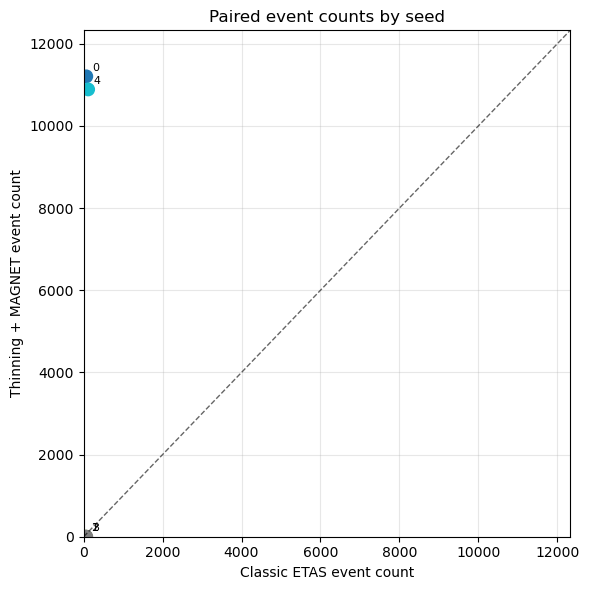

In [5]:
paired_metrics = pd.DataFrame({"seed": selected_seeds})

for method, catalogs in catalogs_by_method.items():
    for seed in selected_seeds:
        cat = catalogs[seed]
        row_mask = paired_metrics["seed"] == seed
        paired_metrics.loc[row_mask, f"{method}_n_events"] = len(cat)
        paired_metrics.loc[row_mask, f"{method}_max_magnitude"] = (
            float(cat["m"].max()) if len(cat) else np.nan
        )
        paired_metrics.loc[row_mask, f"{method}_median_iet_days"] = median_interevent_days(cat)
        if "event_source" in cat.columns:
            for sub in ("background", "triggered"):
                paired_metrics.loc[row_mask, f"{method}_{sub}"] = int(
                    (cat["event_source"] == sub).sum()
                )
            n = paired_metrics.loc[row_mask, f"{method}_n_events"].values[0]
            paired_metrics.loc[row_mask, f"{method}_bg_frac"] = (
                paired_metrics.loc[row_mask, f"{method}_background"].values[0] / n
                if n
                else np.nan
            )

display(Markdown("**Per-realization metrics:**"))
display(paired_metrics)

if len(methods) >= 2:
    m0, m1 = methods[0], methods[1]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(
        paired_metrics[f"{m0}_n_events"],
        paired_metrics[f"{m1}_n_events"],
        c=paired_metrics["seed"],
        cmap="tab10",
        s=80,
    )
    lims = [
        min(paired_metrics[f"{m0}_n_events"].min(), paired_metrics[f"{m1}_n_events"].min()) * 0.9,
        max(paired_metrics[f"{m0}_n_events"].max(), paired_metrics[f"{m1}_n_events"].max()) * 1.1,
    ]
    ax.plot(lims, lims, "k--", lw=1.0, alpha=0.6)
    for _, row in paired_metrics.iterrows():
        ax.annotate(
            int(row["seed"]),
            (row[f"{m0}_n_events"], row[f"{m1}_n_events"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f"{METHOD_LABELS[m0]} event count")
    ax.set_ylabel(f"{METHOD_LABELS[m1]} event count")
    ax.set_title("Paired event counts by seed")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    show_fig(fig)
else:
    display(Markdown("_Single method — skip pairwise count scatter._"))


## Tier 1 — cumulative count and rate


2026-07-14 11:16:01.722901: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-14 11:16:01.756630: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-14 11:16:01.756666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-14 11:16:01.757835: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-14 11:16:01.764310: I tensorflow/core/platform/cpu_feature_guar

2026-07-14 11:16:03,452 - INFO - Loading Calculation...
2026-07-14 11:16:03,453 - INFO -   model is named NoName ETAS Model, has ID 219e51f42e5469be
2026-07-14 11:16:03,455 - INFO -   Time Window: 
      2016-01-01 00:00:00 (aux start)
      2017-01-01 00:00:00 (start)
      2018-10-01 00:00:00 (end).
2026-07-14 11:16:03,455 - INFO -   free_productivity: False, free_background: False
2026-07-14 11:16:03,469 - INFO -   228 out of 4454 events are within time window.
2026-07-14 11:16:03,470 - INFO -   Coordinates of region: [array([  43.5, -125.7]), array([  43.5, -118.5]), array([  39.7, -118.5]), array([  36.1, -113.6]), array([  34.6, -112.6]), array([  34.3, -112.6]), array([  32.7, -113.1]), array([  31.8, -113.2]), array([  31.2, -114.5]), array([  31. , -117.1]), array([  31.1, -117.4]), array([  31.5, -118.3]), array([  32.4, -118.8]), array([  33.3, -121.3]), array([  34., -122.]), array([  37.5, -124.3]), array([  40. , -125.9]), array([  40.5, -125.9]), array([  43. , -125.7]),

/tmp/ipykernel_3138785/1435699602.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


2026-07-14 11:16:03,720 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/noto/NotoSansModi-Regular.ttf', name='Noto Sans Modi', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-14 11:16:03,721 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/croscore/Cousine-Bold.ttf', name='Cousine', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-07-14 11:16:03,721 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/open-sans/OpenSans-SemiboldItalic.ttf', name='Open Sans', style='italic', variant='normal', weight=600, stretch='normal', size='scalable')) = 11.24
2026-07-14 11:16:03,721 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/lyx/eufm10.ttf', name='eufm10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-14 11:16:03,721 - DEBUG - findfont: score(FontEntry(fname='/usr/share/

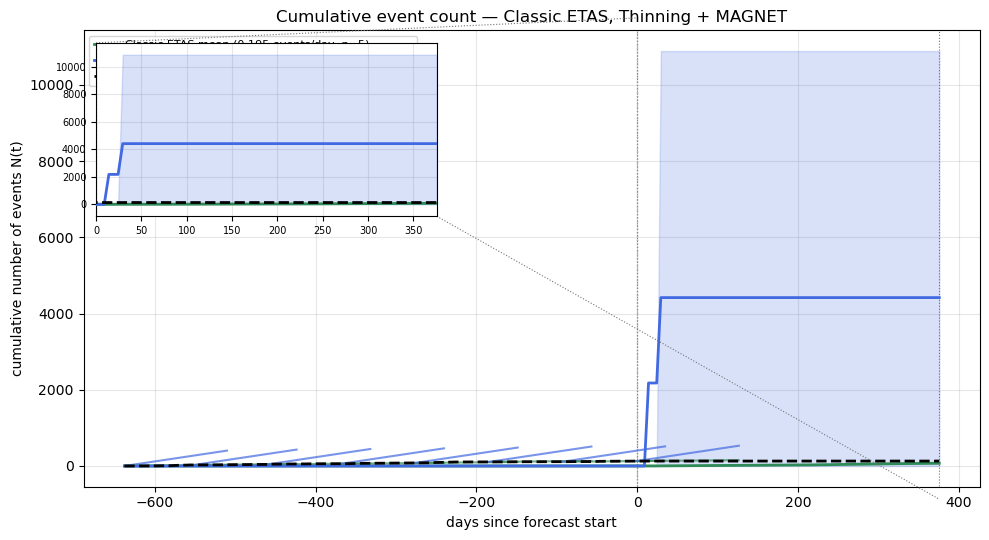

/tmp/ipykernel_3138785/1435699602.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


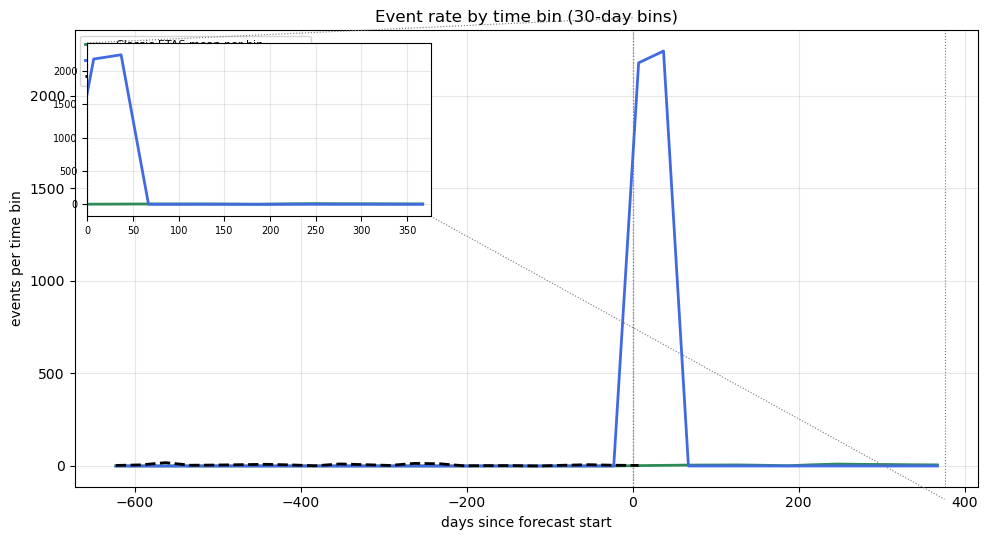

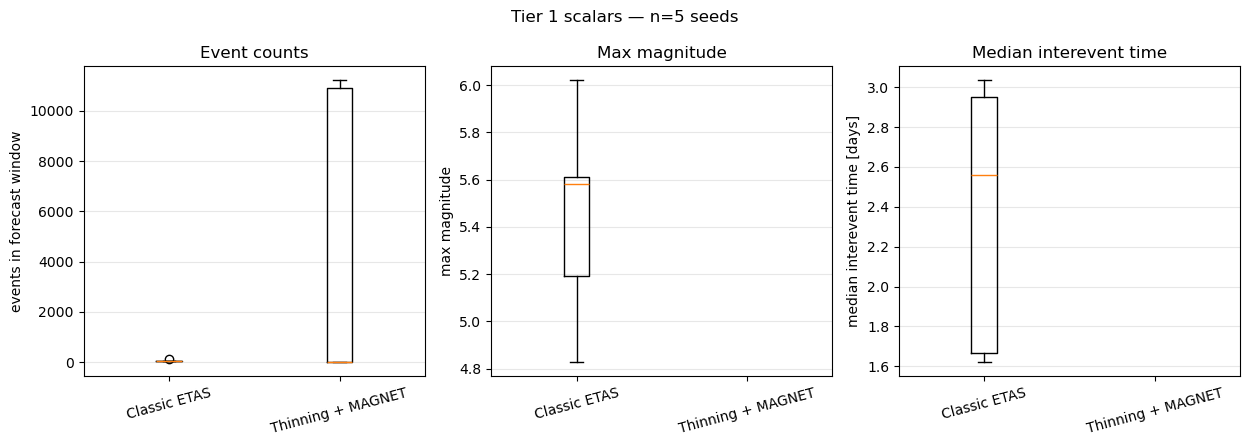

In [6]:
try:
    ctx = load_intensity_context(OUTPUT_ROOT, primary_dir, primary_meta, selected_seeds[0])
    mc_val = float(ctx["mc"])
    forecast_days = float(ctx["forecast_days"])
    timewindow_start = ctx.get("timewindow_start")
    timewindow_end = ctx.get("timewindow_end")
    train_dt_days = np.array([], dtype=float)
    train_days = 0.0
    if timewindow_start and timewindow_end:
        train_start_dt = pd.to_datetime(timewindow_start, utc=True).tz_convert(None)
        train_end_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
        train_df = ctx["history_df"].loc[
            (ctx["history_df"]["time"] >= train_start_dt)
            & (ctx["history_df"]["time"] <= train_end_dt)
        ]
        train_dt_days = train_df["t"].to_numpy(dtype=float) - ctx["forecast_start_t"]
        train_days = float((train_end_dt - train_start_dt).total_seconds() / 86400.0)
except Exception as exc:
    display(Markdown(f"_Could not load inversion context ({exc}); using catalog times only._"))
    all_dt = np.concatenate(
        [cat["dt_days"].to_numpy() for catalogs in catalogs_by_method.values() for cat in catalogs.values()]
    )
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0
    train_dt_days = np.array([], dtype=float)
    train_days = 0.0
    mc_val = float("nan")

t_grid = np.linspace(-train_days, forecast_days, 200)
curves_by_method = {
    method: np.vstack(
        [cumulative_on_grid(catalogs[s]["dt_days"].to_numpy(), t_grid) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
forecast_mask = t_grid >= 0.0
slopes_by_method = {
    method: float(np.polyfit(t_grid[forecast_mask], arr.mean(axis=0)[forecast_mask], 1)[0])
    for method, arr in curves_by_method.items()
}

cum_ylim_curves = [arr.mean(axis=0) for arr in curves_by_method.values()]
for arr in curves_by_method.values():
    if arr.shape[0] > 1:
        q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        cum_ylim_curves.extend([q25, q75])
cum_test_ylims = ylim_in_xrange(t_grid, cum_ylim_curves, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_cumulative_event_count(
    ax,
    t_grid=t_grid,
    curves_by_method=curves_by_method,
    slopes_by_method=slopes_by_method,
    train_dt_days=train_dt_days,
    train_days=train_days,
    show_training_slopes=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events N(t)")
ax.set_title(f"Cumulative event count — {', '.join(METHOD_LABELS[m] for m in methods)}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_cumulative_event_count(
        axins,
        t_grid=t_grid,
        curves_by_method=curves_by_method,
        slopes_by_method=slopes_by_method,
        train_dt_days=train_dt_days,
        train_days=train_days,
        show_training_slopes=False,
        show_legend=False,
    ),
    ylims=cum_test_ylims,
)
fig.tight_layout()
show_fig(fig)

BIN_LENGTH_DAYS = 30.0
t_min, t_max = -train_days, forecast_days
n_bins = max(1, int(np.ceil((t_max - t_min) / BIN_LENGTH_DAYS)))
bin_edges = t_min + np.arange(n_bins + 1, dtype=float) * BIN_LENGTH_DAYS
if bin_edges[-1] < t_max:
    bin_edges = np.append(bin_edges, t_max)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_curves_by_method = {
    method: np.vstack(
        [events_per_time_bin(catalogs[s]["dt_days"].to_numpy(), bin_edges) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
bin_means = [arr.mean(axis=0) for arr in bin_curves_by_method.values()]
bin_test_ylims = ylim_in_xrange(bin_centers, bin_means, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_event_rate_by_bin(
    ax,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    bin_curves_by_method=bin_curves_by_method,
    train_dt_days=train_dt_days,
    include_training=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events per time bin")
ax.set_title(f"Event rate by time bin ({BIN_LENGTH_DAYS:g}-day bins)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_event_rate_by_bin(
        axins,
        bin_centers=bin_centers,
        bin_edges=bin_edges,
        bin_curves_by_method=bin_curves_by_method,
        train_dt_days=train_dt_days,
        include_training=False,
        show_legend=False,
    ),
    ylims=bin_test_ylims,
)
fig.tight_layout()
show_fig(fig)

# Scalar boxplots
n_panels = 3
fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 4.5))
count_series = [paired_metrics[f"{m}_n_events"] for m in methods]
axes[0].boxplot(count_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[0].set_ylabel("events in forecast window")
axes[0].set_title("Event counts")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(True, alpha=0.3, axis="y")

max_m_series = [paired_metrics[f"{m}_max_magnitude"] for m in methods]
axes[1].boxplot(max_m_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[1].set_ylabel("max magnitude")
axes[1].set_title("Max magnitude")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, alpha=0.3, axis="y")

iet_series = [paired_metrics[f"{m}_median_iet_days"] for m in methods]
axes[2].boxplot(iet_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[2].set_ylabel("median interevent time [days]")
axes[2].set_title("Median interevent time")
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 1 scalars — n={len(selected_seeds)} seeds", fontsize=12)
fig.tight_layout()
show_fig(fig)


## Tier 2 — pooled magnitude and interevent-time distributions


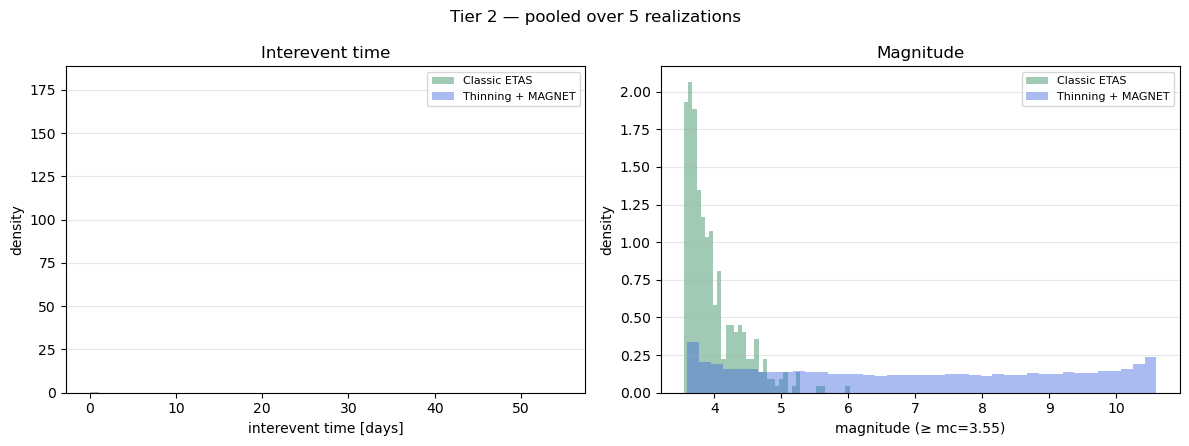

**Tier 2 — pairwise KS tests:**

,comparison,quantity,KS statistic,p-value
0,Classic ETAS vs Thinning + MAGNET,interevent time,0.999502,0.000000e+00
1,Classic ETAS vs Thinning + MAGNET,magnitude,0.728176,2.092202e-192


In [7]:
pooled_iet = {
    method: np.concatenate(
        [interevent_times(catalogs[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
pooled_m = {}
for method, catalogs in catalogs_by_method.items():
    m_all = np.concatenate([catalogs[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
    if np.isfinite(mc_val):
        m_all = m_all[m_all >= mc_val]
    pooled_m[method] = m_all

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for method in methods:
    if pooled_iet[method].size:
        axes[0].hist(
            pooled_iet[method],
            bins=50,
            density=True,
            alpha=0.45,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )
    if pooled_m[method].size:
        axes[1].hist(
            pooled_m[method],
            bins=40,
            density=True,
            alpha=0.45,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )
axes[0].set_xlabel("interevent time [days]")
axes[0].set_ylabel("density")
axes[0].set_title("Interevent time")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")
axes[1].set_xlabel(f"magnitude (≥ mc={mc_val:.2f})" if np.isfinite(mc_val) else "magnitude")
axes[1].set_ylabel("density")
axes[1].set_title("Magnitude")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")
fig.suptitle(f"Tier 2 — pooled over {len(selected_seeds)} realizations", fontsize=12)
fig.tight_layout()
show_fig(fig)

if len(methods) >= 2:
    ks_rows = []
    for i, ma in enumerate(methods):
        for mb in methods[i + 1 :]:
            for name, store in [("interevent time", pooled_iet), ("magnitude", pooled_m)]:
                a_data, b_data = store[ma], store[mb]
                if a_data.size and b_data.size:
                    stat, pval = stats.ks_2samp(a_data, b_data)
                    ks_rows.append(
                        {
                            "comparison": f"{METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}",
                            "quantity": name,
                            "KS statistic": stat,
                            "p-value": pval,
                        }
                    )
    display(Markdown("**Tier 2 — pairwise KS tests:**"))
    display(pd.DataFrame(ks_rows))


## Formal tests (when ≥ 2 methods)


In [8]:
if len(methods) < 2:
    display(Markdown("_Fewer than 2 methods — skip paired formal tests._"))
else:
    formal_rows = []
    n_perm = 5000
    rng = np.random.default_rng(0)
    for i, ma in enumerate(methods):
        for mb in methods[i + 1 :]:
            a_counts = paired_metrics[f"{ma}_n_events"].to_numpy(dtype=float)
            b_counts = paired_metrics[f"{mb}_n_events"].to_numpy(dtype=float)
            paired_diff = b_counts - a_counts
            if len(selected_seeds) >= 2 and np.any(paired_diff != 0):
                w_stat, w_p = stats.wilcoxon(b_counts, a_counts)
            else:
                w_stat, w_p = np.nan, np.nan
            if len(selected_seeds) >= 2:
                pr, pp = stats.pearsonr(a_counts, b_counts)
            else:
                pr, pp = np.nan, np.nan
            obs = float(paired_diff.mean())
            perm = np.empty(n_perm)
            for k in range(n_perm):
                signs = rng.choice([-1.0, 1.0], size=len(paired_diff))
                perm[k] = (signs * paired_diff).mean()
            perm_p = float((np.abs(perm) >= abs(obs)).mean())
            label = f"{METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}"
            formal_rows.extend(
                [
                    {"pair": label, "test": "Paired Wilcoxon (counts)", "statistic": w_stat, "p-value": w_p},
                    {"pair": label, "test": "Pearson r (counts)", "statistic": pr, "p-value": pp},
                    {"pair": label, "test": "Permutation mean Δcount", "statistic": obs, "p-value": perm_p},
                ]
            )
    display(Markdown("**Formal tests:**"))
    display(pd.DataFrame(formal_rows))


**Formal tests:**

,pair,test,statistic,p-value
0,Classic ETAS vs Thinning + MAGNET,Paired Wilcoxon (counts),6.000000,0.812500
1,Classic ETAS vs Thinning + MAGNET,Pearson r (counts),0.684451,0.202407
2,Classic ETAS vs Thinning + MAGNET,Permutation mean Δcount,4347.400000,0.500600


## MAGNET Kumaraswamy forecast samples

Shown only when `thinning_magnet` is loaded **and** a `magnet_predictions.npz` sidecar
exists for the chosen seed (enable with `magnet.save_predictions` or
`--save-magnet-predictions` in `run_continuation_models.py`).

Control which events to plot via the **User config** cell:

| Setting | Meaning |
|---|---|
| `MAGNET_PRED_SEED` | Realization seed (`None` → first seed with a sidecar) |
| `KUMA_EVENT_MODE` | `indices` / `largest_m` / `first_n` / `magnitude_range` |
| `KUMA_EVENT_INDICES` | Explicit 0-based row indices (when mode=`indices`) |
| `KUMA_N_EVENTS` | How many PDFs to draw |
| `KUMA_MAG_RANGE` | Magnitude window for `magnitude_range` |

Row index `i` refers to the `i`-th entry in `magnet_predictions.npz` (aligned with
forecast order; `event_index` in the sidecar may be constant when MAGNET is called
one event at a time).


**MAGNET predictions:** seed `0` → `/home/neriberman/Repos/etas/outputs/continuation_models/thinning_magnet/inv_219e51f42e5469be/seed_0/magnet_predictions.npz` (11271 rows)

PDF support: shift (mc) = `3.6`, stretch = `7.0`

**Selected events** (`largest_m`): `[8837, 431, 894, 9729, 10105, 10007]` — magnitudes `[10.6, 10.6, 10.599, 10.599, 10.599, 10.599]`

2026-07-14 11:16:04,540 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=9.0.
2026-07-14 11:16:04,540 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-14 11:16:04,540 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-14 11:16:04,541 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

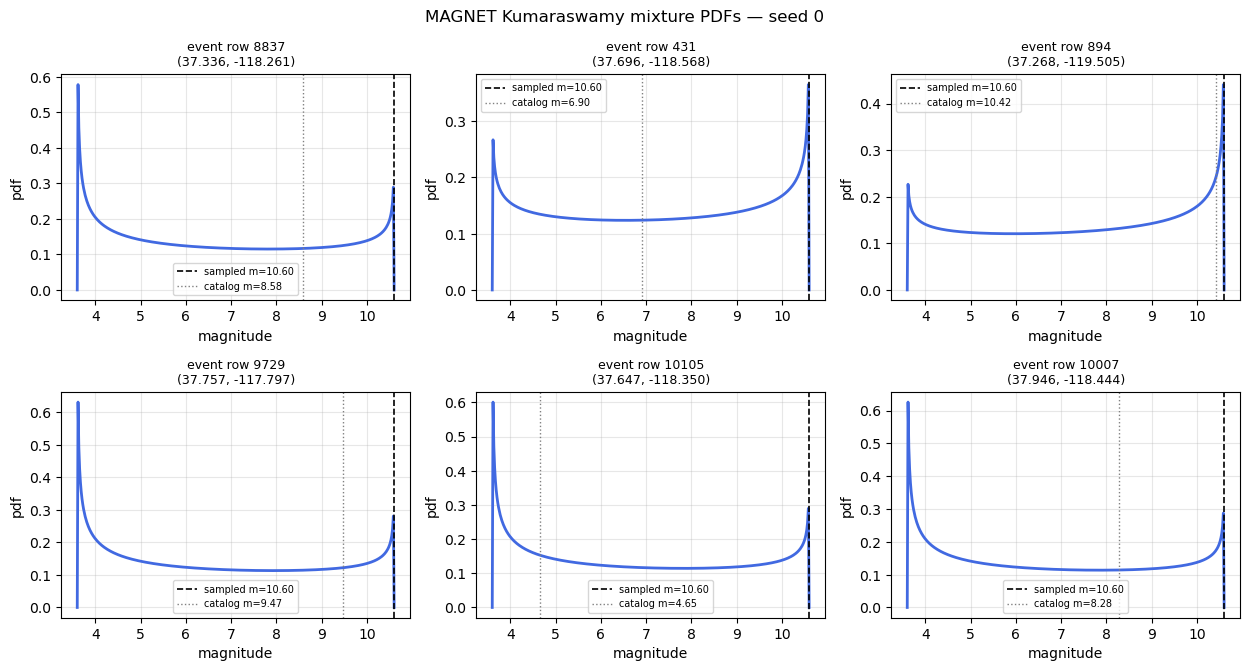

**Selected events (set `KUMA_EVENT_MODE='indices'` + `KUMA_EVENT_INDICES` to lock these):**

,row,magnitude,latitude,longitude,time_unix
0,8837,10.599730,37.335736,-118.261209,1539732504
1,431,10.599569,37.695542,-118.567989,1539732502
2,894,10.599478,37.268355,-119.505349,1539732502
3,9729,10.599388,37.756538,-117.797186,1539732504
4,10105,10.598914,37.646713,-118.350190,1539732504
5,10007,10.598837,37.945804,-118.444019,1539732504


In [9]:
HAS_MAGNET = "thinning_magnet" in catalogs_by_method
magnet_preds = None
magnet_seed_used = None
magnet_run_dir = None

if not HAS_MAGNET:
    display(Markdown("_`thinning_magnet` not in methods — skip Kumaraswamy samples._"))
else:
    magnet_dir = ensemble_dirs["thinning_magnet"]
    candidate_seeds = (
        [MAGNET_PRED_SEED] if MAGNET_PRED_SEED is not None else list(selected_seeds)
    )
    for seed in candidate_seeds:
        run_dir = realization_dir(magnet_dir, seed)
        preds = load_magnet_predictions(run_dir)
        if preds is not None:
            magnet_preds = preds
            magnet_seed_used = seed
            magnet_run_dir = run_dir
            break

    if magnet_preds is None:
        display(Markdown(
            f"_No `{_MAGNET_PREDICTIONS_NAME}` under `{magnet_dir}` for seeds "
            f"{candidate_seeds}. Re-run with `--save-magnet-predictions`._"
        ))
    else:
        display(Markdown(
            f"**MAGNET predictions:** seed `{magnet_seed_used}` → `{magnet_run_dir / _MAGNET_PREDICTIONS_NAME}` "
            f"({len(magnet_preds['magnitude'])} rows)"
        ))

        mag_meta = metas_by_method["thinning_magnet"]
        model_dir = Path(mag_meta["thinning_model_dir"]) if mag_meta.get("thinning_model_dir") else None
        shift, stretch = parse_magnet_shift_stretch(model_dir, mc_val)
        display(Markdown(f"PDF support: shift (mc) = `{shift}`, stretch = `{stretch}`"))

        mags = np.asarray(magnet_preds["magnitude"], dtype=float)
        preds_arr = np.asarray(magnet_preds["model_prediction"])
        event_ids = select_kuma_event_indices(
            mags,
            mode=KUMA_EVENT_MODE,
            indices=KUMA_EVENT_INDICES,
            n_events=KUMA_N_EVENTS,
            mag_range=KUMA_MAG_RANGE,
        )
        display(Markdown(
            f"**Selected events** (`{KUMA_EVENT_MODE}`): `{event_ids}` — "
            f"magnitudes `{[round(float(mags[i]), 3) for i in event_ids]}`"
        ))

        # Catalog alignment for annotation (npz may be longer if truncated mid-run).
        catalog = catalogs_by_method["thinning_magnet"][magnet_seed_used]
        n_align = min(len(catalog), len(mags))

        if KUMA_M_GRID is None:
            m_lo = float(shift)
            m_hi = float(shift + stretch)
            n_grid = 400
        else:
            m_lo, m_hi, n_grid = KUMA_M_GRID
        m_grid = np.linspace(m_lo, m_hi, int(n_grid))

        n_show = len(event_ids)
        n_cols = min(3, max(1, n_show))
        n_rows = int(math.ceil(n_show / n_cols)) if n_show else 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows), squeeze=False)
        for ax in axes.ravel():
            ax.set_visible(False)

        for panel_i, event_i in enumerate(event_ids):
            ax = axes[panel_i // n_cols][panel_i % n_cols]
            ax.set_visible(True)
            pred_row = preds_arr[event_i]
            pdf = magnitude_pdf_from_prediction(m_grid, pred_row, shift=shift, stretch=stretch)
            ax.plot(m_grid, pdf, color=METHOD_COLORS["thinning_magnet"], lw=2.0)
            sampled_m = float(mags[event_i])
            ax.axvline(sampled_m, color="black", ls="--", lw=1.2, label=f"sampled m={sampled_m:.2f}")
            if event_i < n_align:
                cat_m = float(catalog.iloc[event_i]["m"])
                if abs(cat_m - sampled_m) > 1e-3:
                    ax.axvline(cat_m, color="gray", ls=":", lw=1.0, label=f"catalog m={cat_m:.2f}")
            lon = float(magnet_preds["longitude"][event_i])
            lat = float(magnet_preds["latitude"][event_i])
            ax.set_title(f"event row {event_i}\n({lat:.3f}, {lon:.3f})", fontsize=9)
            ax.set_xlabel("magnitude")
            ax.set_ylabel("pdf")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7)

        fig.suptitle(
            f"MAGNET Kumaraswamy mixture PDFs — seed {magnet_seed_used}",
            fontsize=12,
        )
        fig.tight_layout()
        show_fig(fig)

        # Table of selected events for easy re-selection via KUMA_EVENT_INDICES
        rows = []
        for event_i in event_ids:
            rows.append(
                {
                    "row": event_i,
                    "magnitude": float(mags[event_i]),
                    "latitude": float(magnet_preds["latitude"][event_i]),
                    "longitude": float(magnet_preds["longitude"][event_i]),
                    "time_unix": int(magnet_preds["time"][event_i]),
                    "pred_params": np.asarray(preds_arr[event_i]).tolist(),
                }
            )
        display(Markdown("**Selected events (set `KUMA_EVENT_MODE='indices'` + `KUMA_EVENT_INDICES` to lock these):**"))
        display(pd.DataFrame(rows).drop(columns=["pred_params"]))
